In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    explained_variance_score,
    max_error
)
from sklearn.datasets import fetch_california_housing

In [2]:
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

In [3]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64

In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [6]:
print(df.shape)
display(df.head())


(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'target'],
      dtype='object')

In [8]:
X = df.drop('target',axis=1)
y = df['target']
X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(16512, 8)
(4128, 8)
(16512,)
(4128,)


In [9]:
from sklearn.pipeline import Pipeline

linear_model = Pipeline([
    ("scale",StandardScaler()),
    ("linear_re",LinearRegression())
])

linear_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scale', ...), ('linear_re', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None


In [10]:
linear_model.fit(X_train,Y_train)

print("Train Done")

Train Done


In [11]:
# Test

linear_train_predictions = linear_model.predict(X_train)
linear_test_predictions = linear_model.predict(X_test)

In [12]:
linear_prediction_table = pd.DataFrame({
    "Actual":Y_test,
    "Predicted":linear_test_predictions
})

linear_prediction_table.head()

,Actual,Predicted
20046,0.47700,0.719123
3024,0.45800,1.764017
15663,5.00001,2.709659
20484,2.18600,2.838926
9814,2.78000,2.604657


In [13]:
def calculate_regression_metrics(y_true,y_pred):
  mae = mean_absolute_error(y_true,y_pred)
  mse = mean_squared_error(y_true,y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_true,y_pred)
  evs = explained_variance_score(y_true,y_pred)
  max_err = max_error(y_true,y_pred)

  metrics_dict = {
      "MAE":mae,
      "MSE":mse,
      "RMSE":rmse,
      "R2":r2,
      "EVS":evs,
      "MAX_ERR":max_err
  }

  return metrics_dict

linear_metrics = calculate_regression_metrics(Y_test,linear_test_predictions)
linear_metrics_train = calculate_regression_metrics(Y_train,linear_train_predictions)

linear_metrics_df = pd.DataFrame(linear_metrics.items(),columns = ["Metric","Value"])
linear_metrics_train_df = pd.DataFrame(linear_metrics_train.items(),columns = ["Metric","Value"])
display(linear_metrics_df)
display(linear_metrics_train_df)

,Metric,Value
0,MAE,0.533200
1,MSE,0.555892
2,RMSE,0.745581
3,R2,0.575788
4,EVS,0.575797
5,MAX_ERR,9.875331


,Metric,Value
0,MAE,0.528628
1,MSE,0.517933
2,RMSE,0.719676
3,R2,0.612551
4,EVS,0.612551
5,MAX_ERR,5.934828


In [14]:
coefs = pd.Series(
    linear_model.named_steps['linear_re'].coef_,
    index=X.columns
).sort_values(key=abs, ascending=False)
print(coefs)

Latitude     -0.896929
Longitude    -0.869842
MedInc        0.854383
AveBedrms     0.339259
AveRooms     -0.294410
HouseAge      0.122546
AveOccup     -0.040829
Population   -0.002308
dtype: float64


In [15]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(linear_model, X, y, cv=5, scoring='r2')
print(scores)
print("Mean R²:", scores.mean(), "+/-", scores.std())

[0.54866323 0.46820691 0.55078434 0.53698703 0.66051406]
Mean R²: 0.5530311140279563 +/- 0.061691601409532636


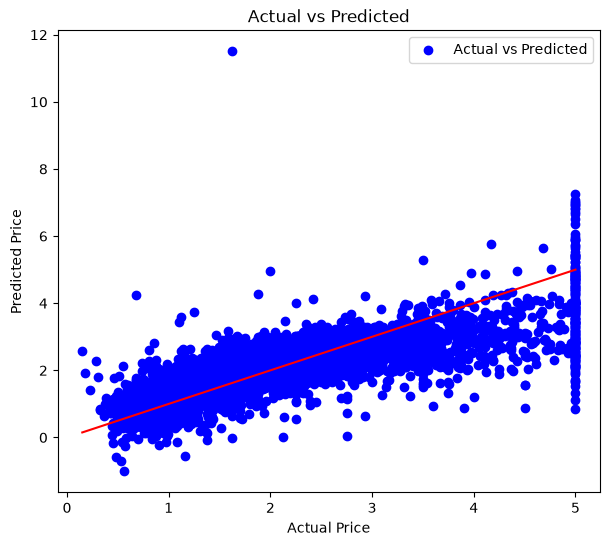

In [16]:
plt.figure(figsize = (7,6))

plt.scatter(Y_test,linear_test_predictions,color = "blue",label = "Actual vs Predicted")
plt.plot([Y_test.min(),Y_test.max()],[Y_test.min(),Y_test.max()], color = "red")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()

In [17]:
from sklearn.datasets import load_diabetes
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

In [18]:
X = df.drop('target',axis=1)
y= df['target']

In [19]:
linear_diab_model = Pipeline([
    ("scaler",StandardScaler()),
    ("linear_reg_dia",LinearRegression())
])
linear_diab_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('linear_reg_dia', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None


In [20]:
X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(353, 10)
(89, 10)
(353,)
(89,)


In [21]:
#Train
linear_diab_model.fit(X_train,Y_train)
print('Training Done')

Training Done


In [22]:
#Test 
linear_diab_train = linear_diab_model.predict(X_train)
linear_diab_test = linear_diab_model.predict(X_test)

In [23]:
linear_metrics_dia_test = calculate_regression_metrics(Y_test,linear_diab_test)
linear_metrics_dia_train = calculate_regression_metrics(Y_train,linear_diab_train)
linear_metrics_dia_test_df = pd.DataFrame(linear_metrics_dia_test.items(),columns = ["Metric","Value"])
linear_metrics_dia_train_df = pd.DataFrame(linear_metrics_dia_train.items(),columns = ["Metric","Value"])
display(linear_metrics_dia_test_df)
display(linear_metrics_dia_train_df)

,Metric,Value
0,MAE,42.794095
1,MSE,2900.193628
2,RMSE,53.853446
3,R2,0.452603
4,EVS,0.455493
5,MAX_ERR,154.493375


,Metric,Value
0,MAE,43.483504
1,MSE,2868.549703
2,RMSE,53.558843
3,R2,0.527919
4,EVS,0.527919
5,MAX_ERR,160.625386


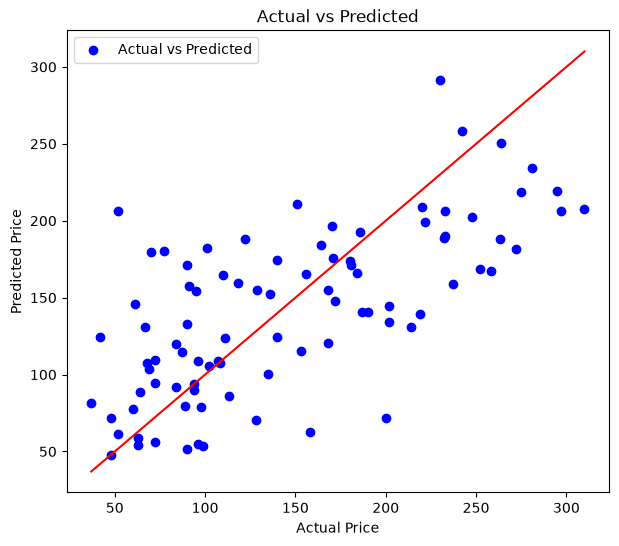

In [24]:
plt.figure(figsize = (7,6))

plt.scatter(Y_test,linear_diab_test,color = "blue",label = "Actual vs Predicted")
plt.plot([Y_test.min(),Y_test.max()],[Y_test.min(),Y_test.max()], color = "red")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()

In [25]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
linear_diab_model_ridge = Pipeline([
    ("scaler",StandardScaler()),
    ("ridge",Ridge(alpha=1.0))
])
linear_diab_model_ridge

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None


In [26]:
linear_diab_model_lasso = Pipeline([
    ("scaler",StandardScaler()),
    ("lasso",Lasso(alpha=0.1))
])
linear_diab_model_lasso

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('lasso', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True


In [27]:
#train ridge
linear_diab_model_ridge.fit(X_train,Y_train)
print('Ridge Training Done')
linear_diab_model_lasso.fit(X_train,Y_train)
print('Lasso Training Done')

Ridge Training Done
Lasso Training Done


In [ ]:
linear_diab_model_ridge_train_predict = linear_diab_model_ridge.predict(X_train)
linear_diab_model_ridge_test_predict = linear_diab_model_ridge.predict(X_test)

In [ ]:
linear_diab_model_lasso_train_predict = linear_diab_model_lasso.predict(X_train)
linear_diab_model_lasso_test_predict = linear_diab_model_lasso.predict(X_test)

In [ ]:
linear_metrics_dia_test_ridge = calculate_regression_metrics(Y_test,linear_diab_model_ridge_test_predict)
linear_metrics_dia_train_rdge = calculate_regression_metrics(Y_train,linear_diab_model_ridge_train_predict)
linear_metrics_dia_test_ridge_df = pd.DataFrame(linear_metrics_dia_test_ridge.items(),columns = ["Metric","Value"])
linear_metrics_dia_train_rdge_df = pd.DataFrame(linear_metrics_dia_train_rdge.items(),columns = ["Metric","Value"])
display(linear_metrics_dia_test_ridge_df)
display(linear_metrics_dia_train_rdge_df)

In [ ]:
linear_metrics_dia_test_lasso = calculate_regression_metrics(Y_test,linear_diab_model_lasso_test_predict)
linear_metrics_dia_train_lasso = calculate_regression_metrics(Y_train,linear_diab_model_lasso_train_predict)
linear_metrics_dia_test_lasso_df = pd.DataFrame(linear_metrics_dia_test_lasso.items(),columns = ["Metric","Value"])
linear_metrics_dia_train_lasso_df = pd.DataFrame(linear_metrics_dia_train_lasso.items(),columns = ["Metric","Value"])
display(linear_metrics_dia_test_lasso_df)
display(linear_metrics_dia_train_lasso_df)

In [ ]:
coef_table = pd.DataFrame({
    "Linear": linear_diab_model.named_steps["linear_reg_dia"].coef_,
    "Ridge":  linear_diab_model_ridge.named_steps["ridge"].coef_,
    "Lasso":  linear_diab_model_lasso.named_steps["lasso"].coef_,  # or "lasso" after you rename
}, index=X.columns)
print(coef_table.round(2))

In [ ]:
import joblib
joblib.dump(linear_diab_model_lasso, "diabetes_model_v1.pkl")

In [ ]:
import joblib
model = joblib.load("diabetes_model_v1.pkl")

# new patient data, same columns as training
prediction = model.predict(X_test)
print(prediction)

In [ ]:
linear_diab_model_lasso_test_predict == prediction

In [ ]:
#Polynomial
poly_model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2)),
    ("linear", LinearRegression())
])
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
X = df.drop('target',axis=1)
y = df['target']
poly_model

In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

In [ ]:
poly_model.fit(X_train,Y_train)

In [ ]:
poly_cal_train_predictions = poly_model.predict(X_train)
poly_cal_test_predictions = poly_model.predict(X_test)

In [ ]:
metrics = calculate_regression_metrics(Y_train,poly_cal_train_predictions)
pd.DataFrame(metrics.items(),columns=['Metrics','values'])

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(poly_model, X, y, cv=5, scoring='r2')
print(scores)
print("Mean R²:", scores.mean(), "+/-", scores.std())

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(
accuracy_score,
confusion_matrix,
classification_report,
roc_curve,
roc_auc_score
)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.data"
df = pd.read_csv(url, header=None)

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print(model.score(X_test, y_test))

In [ ]:
df.head()

In [ ]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.data"
df = pd.read_csv(url, header=None)

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000)),
])

pipe.fit(X_train, y_train)
print(pipe.score(X_test, y_test))